# 1.3 Separability and low rank

1.3 Separability and low rank: PSNR-against-r for disk, LoG, motion-45deg
and random kernels at k=21, on the top-left 512x512 crop of base_2048.png,
measured against exact convolution (conv2d_fft). Also shows the singular
value spectra (linear, not log, to show decay rate/energy concentration)
for the discussion of why disk needs few terms and motion-45deg needs all.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import kernel_bank, conv2d_fft, conv2d_lowrank, psnr

ROOT = Path.cwd().parents[1]

In [4]:
K = 21
full = np.asarray(Image.open(ROOT / "Images/input/P1/base_2048.png")).astype(float)
crop = full[:512, :512]

In [5]:
bank = kernel_bank(K)
kernels_of_interest = ["disk", "log", "motion_45deg", "random"]

results = {}
spectra = {}
for name in kernels_of_interest:
    kernel = bank[name]
    ref = conv2d_fft(crop, kernel)
    s = np.linalg.svd(kernel, compute_uv=False)
    spectra[name] = s
    psnrs = []
    for r in range(1, K + 1):
        approx = conv2d_lowrank(crop, kernel, r)
        psnrs.append(psnr(approx, ref, peak=np.abs(ref).max()))
    results[name] = psnrs
    print(f"{name:14s} PSNR(r=1)={psnrs[0]:7.2f}  PSNR(r=3)={psnrs[2]:7.2f}  "
          f"PSNR(r=10)={psnrs[9]:7.2f}  PSNR(r={K})={psnrs[-1]:7.2f}")

disk           PSNR(r=1)=  41.42  PSNR(r=3)=  70.99  PSNR(r=10)= 300.03  PSNR(r=21)= 300.03


log            PSNR(r=1)=   1.03  PSNR(r=3)= 310.46  PSNR(r=10)= 310.46  PSNR(r=21)= 310.46


motion_45deg   PSNR(r=1)=   1.50  PSNR(r=3)=   2.40  PSNR(r=10)=   6.66  PSNR(r=21)= 310.04


random         PSNR(r=1)=   7.78  PSNR(r=3)=  13.87  PSNR(r=10)=  10.55  PSNR(r=21)= 299.78


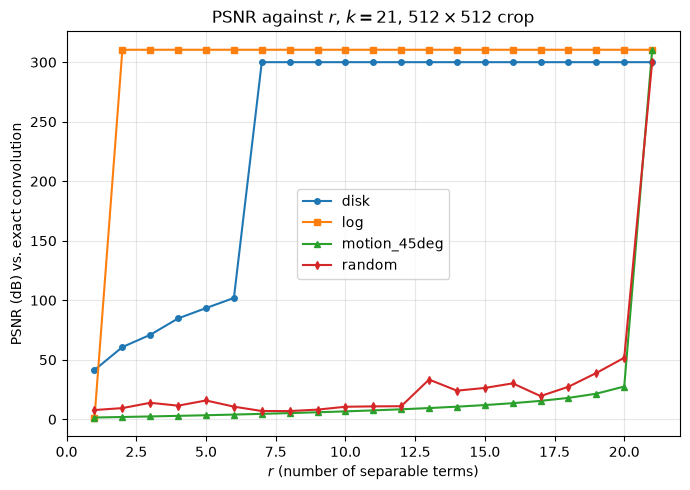

In [6]:
# --- PSNR vs r plot ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
markers = {"disk": "o", "log": "s", "motion_45deg": "^", "random": "d"}
for name in kernels_of_interest:
    ax.plot(range(1, K + 1), results[name], marker=markers[name], label=name, markersize=4)
ax.set_xlabel("$r$ (number of separable terms)")
ax.set_ylabel("PSNR (dB) vs. exact convolution")
ax.set_title(f"PSNR against $r$, $k={K}$, $512\\times512$ crop")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

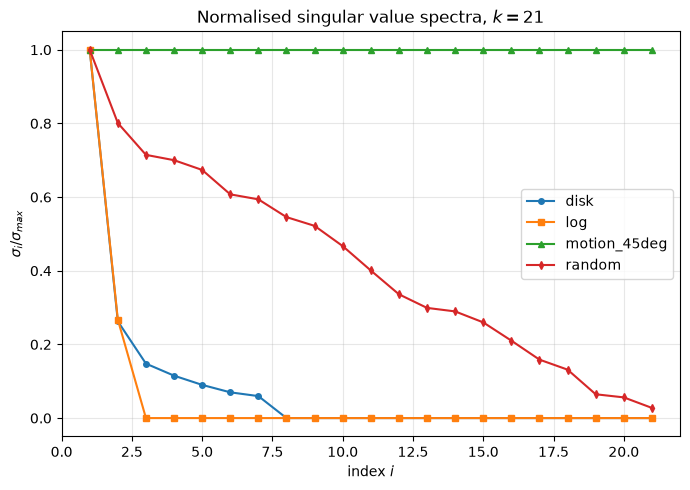

In [7]:
# --- Singular value spectra (linear scale, normalised) for the discussion --
fig, ax = plt.subplots(figsize=(7, 5))
for name in kernels_of_interest:
    s = spectra[name]
    ax.plot(range(1, K + 1), s / s.max(), marker=markers[name], label=name, markersize=4)
ax.set_xlabel("index $i$")
ax.set_ylabel("$\\sigma_i / \\sigma_{max}$")
ax.set_title(f"Normalised singular value spectra, $k={K}$")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [8]:
# --- energy concentration table (cumulative sigma_i^2 / total) -------------
print("\nCumulative energy fraction (sum sigma_i^2 up to r) / (sum sigma_i^2 total):")
print(f"{'kernel':14s} {'rank':>5s} {'r=1':>8s} {'r=3':>8s} {'r=10':>8s}")
for name in kernels_of_interest:
    s = spectra[name]
    energy = np.cumsum(s**2) / np.sum(s**2)
    rank = int(np.sum(s > (max(s.shape) if hasattr(s, "shape") else K) * s.max() * np.finfo(float).eps))
    print(f"{name:14s} {rank:5d} {energy[0]*100:7.2f}% {energy[2]*100:7.2f}% {energy[9]*100:7.2f}%")


Cumulative energy fraction (sum sigma_i^2 up to r) / (sum sigma_i^2 total):
kernel          rank      r=1      r=3     r=10
disk               7   89.23%   97.34%  100.00%
log                2   93.33%  100.00%  100.00%
motion_45deg      21    4.76%   14.29%   47.62%
random            21   19.17%   41.27%   88.32%
